Jason Stys

CS478-01

 CA3: Implement a Shallow Neural Network

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train.shape: (60000, 28, 28)
y_train.shape: (60000,)
First 12 labels: [5 0 4 1 9 2 1 3 1 4 3 5]


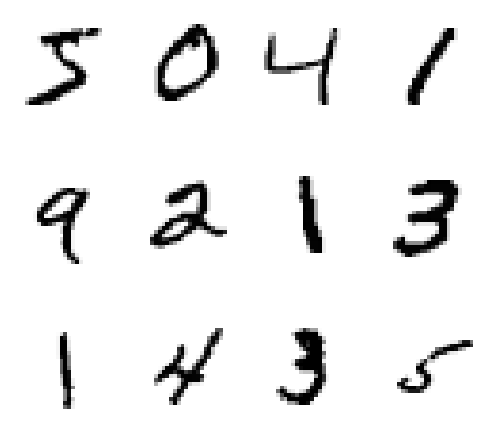

X_valid.shape: (10000, 28, 28)
y_valid.shape: (10000,)


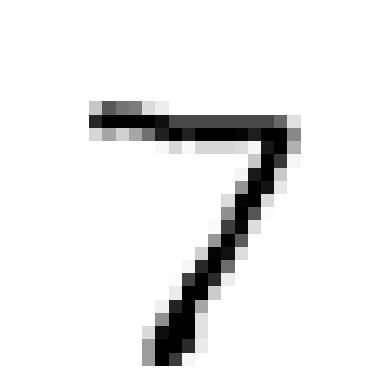

X_valid[0] (pixel grid):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 2

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

(64 * 784) = 50176
(64 * 784) + 64 = 50240
(10 * 64) + 10 = 650
Total params = 50890
Epoch 1/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0503 - loss: 0.0949 - val_accuracy: 0.0621 - val_loss: 0.0928
Epoch 2/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0638 - loss: 0.0925 - val_accuracy: 0.0776 - val_loss: 0.0916
Epoch 3/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0816 - loss: 0.0914 - val_accuracy: 0.0915 - val_loss: 0.0909
Epoch 4/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0945 - loss: 0.0908 - val_accuracy: 0.1079 - val_loss: 0.0904
Epoch 5/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1113 - loss: 0.0903 - val_accuracy: 0.1267 - val_loss: 0.0900
Epoch 6/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1283 - loss: 0.0900 - val_accuracy: 0.1495 - val_loss: 0.0896
Epoch 7/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1543 - loss: 0.0897 - val_accuracy: 0.1715 - val_loss: 0.0893
Epoch 8/200


KeyboardInterrupt: 

In [ ]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt

# Keras
try:
    import keras
    from keras.datasets import mnist
    from keras.models import Sequential
    from keras.layers import Dense
    from keras.optimizers import SGD
except Exception:
    from tensorflow import keras
    from tensorflow.keras.datasets import mnist
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense
    from tensorflow.keras.optimizers import SGD

np.random.seed(0)


# Load data
(X_train, y_train), (X_valid, y_valid) = mnist.load_data()

print("X_train.shape:", X_train.shape)  # expected (60000, 28, 28)
print("y_train.shape:", y_train.shape)  # expected (60000,)
print("First 12 labels:", y_train[0:12])

# 3×4 gallery of the first 12 training images (grayscale, no axes, 5"x5")
plt.figure(figsize=(5, 5))
for k in range(12):
    plt.subplot(3, 4, k + 1)
    plt.imshow(X_train[k], cmap="Greys")
    plt.axis("off")
plt.tight_layout()
plt.show()



# Data insights
print("X_valid.shape:", X_valid.shape)  # expected (10000, 28, 28)
print("y_valid.shape:", y_valid.shape)  # expected (10000,)

plt.imshow(X_valid[0], cmap="Greys")
plt.axis("off")
plt.show()

print("X_valid[0] (pixel grid):")
print(X_valid[0])

print("y_valid[0] (label):", y_valid[0])


# Preprocess data
# Flatten 28×28 images into 784-element arrays and convert to float32
X_train = X_train.reshape(X_train.shape[0], 784).astype("float32")
X_valid = X_valid.reshape(X_valid.shape[0], 784).astype("float32")

# Normalize pixel values to [0, 1]
X_train /= 255.0
X_valid /= 255.0

print("X_valid[0] after flatten+normalize (first 20 values):")
print(X_valid[0][:20])

# One-hot encode labels (10 classes)
n_classes = 10
y_train = keras.utils.to_categorical(y_train, n_classes)
y_valid = keras.utils.to_categorical(y_valid, n_classes)

print("y_valid[0] after one-hot encoding:")
print(y_valid[0])



# Design NN shallow network

model = Sequential()
model.add(Dense(64, activation="sigmoid", input_shape=(784,)))
model.add(Dense(10, activation="softmax"))

model.summary()

# Parameter count checks
print("(64 * 784) =", 64 * 784)
print("(64 * 784) + 64 =", (64 * 784) + 64)
print("(10 * 64) + 10 =", (10 * 64) + 10)
print("Total params =", (784 * 64) + 64 + (64 * 10) + 10)



# Configure model
model.compile(
    loss="mean_squared_error",
    optimizer=SGD(learning_rate=0.01),
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=200,
    verbose=1,
    validation_data=(X_valid, y_valid)
)

eval_loss, eval_acc = model.evaluate(X_valid, y_valid, verbose=1)
print("Validation loss:", eval_loss)
print("Validation accuracy:", eval_acc)
